<a href="https://colab.research.google.com/github/rag-dev1511/DATA_CLEANING_REPORTING/blob/main/data_cleaning_reporting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 : IMPORTS AND UPLOAD

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files

os.makedirs("output", exist_ok=True)

uploaded = files.upload()          # choose data_cleaning_reporting.csv
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(filename)
print("Loaded:", filename, df_raw.shape)
df_raw.head()

Saving data_cleaning_reporting.csv to data_cleaning_reporting (1).csv
Loaded: data_cleaning_reporting (1).csv (3547, 8)


,goods-title-link--jump,goods-title-link--jump href,rank-title,rank-sub,price,selling_proposition,discount,goods-title-link
0,Customized Personalized Heart-Shaped Lace Name...,https://us.shein.com/Customized-Personalized-H...,#3 Best Sellers,in Customized Fashion Word Necklaces,$6.40,NaN,NaN,NaN
1,"24pcs/Set Simple Heart, Butterfly, Flower, Rhi...",https://us.shein.com/24pcs-Set-Simple-Heart-Bu...,NaN,NaN,$2.10,7.2k+ sold recently,NaN,NaN
2,"A Multi-Functional Electronic Watch With 1.44""...",https://us.shein.com/A-Multi-Functional-Electr...,#7 Best Sellers,in Women Digital Watches,$8.20,NaN,-10%,NaN
3,91pcs/Set Fashionable Elegant Vintage Multi-El...,https://us.shein.com/91pcs-Set-Fashionable-Ele...,#9 Best Sellers,in Women Jewelry Sets,$1.50,NaN,NaN,NaN
4,Multi-pack Random Mix-color Popular Bohemian R...,https://us.shein.com/Multi-pack-Random-Mix-col...,NaN,NaN,$1.10,7.4k+ sold recently,NaN,NaN


STEP 2 : INSPECT THE RAW  DATA

In [5]:
df_raw.info()
print(df_raw.isnull().sum())
print("Duplicates:", df_raw.duplicated().sum())
df_raw.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   goods-title-link--jump       39 non-null     object
 1   goods-title-link--jump href  39 non-null     object
 2   rank-title                   716 non-null    object
 3   rank-sub                     716 non-null    object
 4   price                        3547 non-null   object
 5   selling_proposition          2736 non-null   object
 6   discount                     1926 non-null   object
 7   goods-title-link             3508 non-null   object
dtypes: object(8)
memory usage: 221.8+ KB
goods-title-link--jump         3508
goods-title-link--jump href    3508
rank-title                     2831
rank-sub                       2831
price                             0
selling_proposition             811
discount                       1621
goods-title-link              

,goods-title-link--jump,goods-title-link--jump href,rank-title,rank-sub,price,selling_proposition,discount,goods-title-link
count,39,39,716,716,3547,2736,1926,3508
unique,39,39,20,262,417,109,82,3242
top,Customized Personalized Heart-Shaped Lace Name...,https://us.shein.com/Customized-Personalized-H...,#1 Best Sellers,in Women Single Ring,$1.60,100+ sold recently,-20%,Round Drop Earrings
freq,1,1,77,9,162,220,291,6


STEP 3 : CLEANING FUNCTIONS

In [6]:
def clean_data(df):
    log = {"rows_before": len(df),
           "missing_before": int(df.isnull().sum().sum())}
    df = df.copy()

    # Rename messy columns
    df = df.rename(columns={
        "goods-title-link--jump": "title_a",
        "goods-title-link--jump href": "product_url",
        "goods-title-link": "title_b",
        "rank-title": "rank_title",
        "rank-sub": "rank_category",
        "selling_proposition": "sold_recently",
        "discount": "discount_pct"})

    # Merge the two title columns into one
    df["title"] = df["title_a"].fillna(df["title_b"])
    df = df.drop(columns=["title_a", "title_b"])

    # Trim spaces, blank -> missing
    for c in df.select_dtypes(include=["object", "string"]).columns:
        df[c] = df[c].astype("string").str.strip().replace("", pd.NA)
    df["title"] = df["title"].str.replace(r"\s+", " ", regex=True)

    # Fix data types
    df["price_usd"] = pd.to_numeric(
        df["price"].str.replace(r"[$,]", "", regex=True), errors="coerce")
    df = df.drop(columns=["price"])
    df["discount_pct"] = pd.to_numeric(
        df["discount_pct"].str.replace(r"[-%]", "", regex=True), errors="coerce")

    # Fix inconsistent rank text: "#5 Best Seller(s)" -> 5
    df["best_seller_rank"] = pd.to_numeric(
        df["rank_title"].str.extract(r"#(\d+)")[0], errors="coerce")
    df["rank_category"] = df["rank_category"].str.replace(r"^in\s+", "", regex=True)

    # "7.2k+ sold recently" -> 7200
    def to_num(s):
        if pd.isna(s):
            return np.nan
        m = pd.Series([s]).str.extract(r"([\d.]+)\s*([kK]?)\+")
        if pd.isna(m.iloc[0, 0]):
            return np.nan
        return float(m.iloc[0, 0]) * (1000 if m.iloc[0, 1].lower() == "k" else 1)
    df["units_sold_recently"] = df["sold_recently"].map(to_num)
    df = df.drop(columns=["rank_title", "sold_recently"])

    # Remove duplicates (after standardizing)
    log["duplicates_removed"] = int(df.duplicated().sum())
    df = df.drop_duplicates()

    # Missing values: a blank discount means no discount
    df["discount_pct"] = df["discount_pct"].fillna(0)
    df["has_discount"] = df["discount_pct"] > 0
    df["is_best_seller"] = df["best_seller_rank"].notna()
    df["rank_category"] = df["rank_category"].fillna("Not ranked")
    # Blank "sold recently" and rank are left as missing on purpose:
    # the site didn't show a label, which doesn't mean zero sales.

    # Drop rows missing the essentials
    df = df.dropna(subset=["title", "price_usd"])

    log["rows_after"] = len(df)
    log["missing_after"] = int(df.isnull().sum().sum())
    return df, log

df_clean, log = clean_data(df_raw)
print(log)
df_clean.head()

{'rows_before': 3547, 'missing_before': 15149, 'duplicates_removed': 180, 'rows_after': 3367, 'missing_after': 6783}


,product_url,rank_category,discount_pct,title,price_usd,best_seller_rank,units_sold_recently,has_discount,is_best_seller
0,https://us.shein.com/Customized-Personalized-H...,Customized Fashion Word Necklaces,0,Customized Personalized Heart-Shaped Lace Name...,6.4,3,NaN,False,True
1,https://us.shein.com/24pcs-Set-Simple-Heart-Bu...,Not ranked,0,"24pcs/Set Simple Heart, Butterfly, Flower, Rhi...",2.1,<NA>,7200.0,False,False
2,https://us.shein.com/A-Multi-Functional-Electr...,Women Digital Watches,10,"A Multi-Functional Electronic Watch With 1.44""...",8.2,7,NaN,True,True
3,https://us.shein.com/91pcs-Set-Fashionable-Ele...,Women Jewelry Sets,0,91pcs/Set Fashionable Elegant Vintage Multi-El...,1.5,9,NaN,False,True
4,https://us.shein.com/Multi-pack-Random-Mix-col...,Not ranked,0,Multi-pack Random Mix-color Popular Bohemian R...,1.1,<NA>,7400.0,False,False


STEP 4 : CHARTS

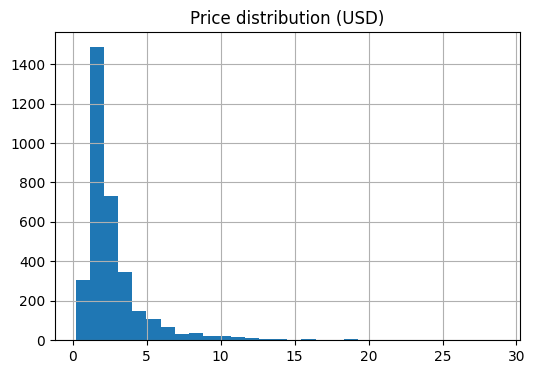

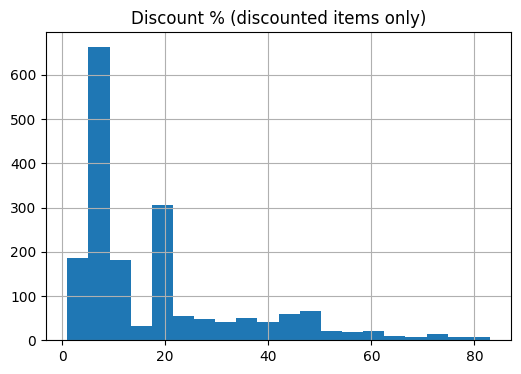

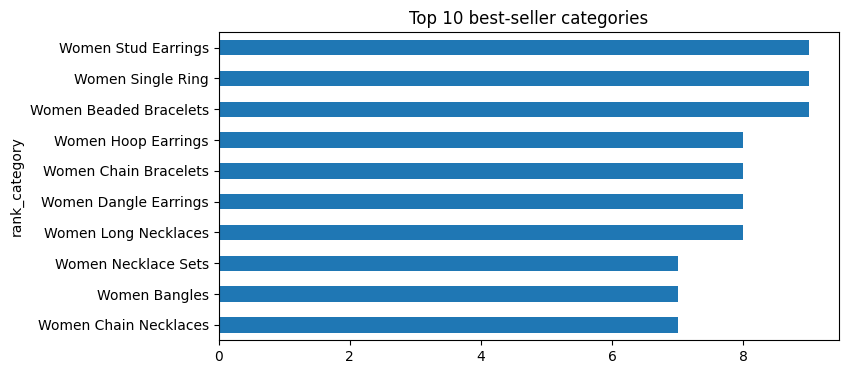

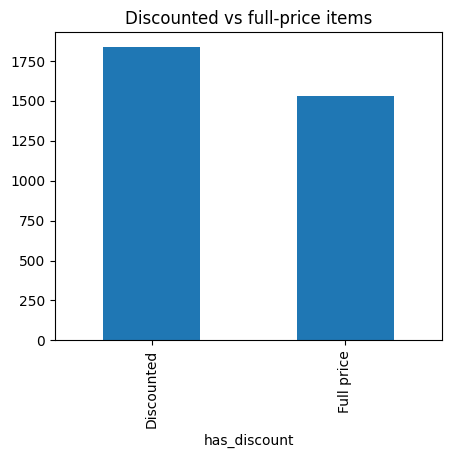

In [7]:
plt.figure(figsize=(6, 4))
df_clean["price_usd"].hist(bins=30)
plt.title("Price distribution (USD)")
plt.savefig("output/hist_price.png", bbox_inches="tight"); plt.show()

plt.figure(figsize=(6, 4))
df_clean.loc[df_clean["discount_pct"] > 0, "discount_pct"].hist(bins=20)
plt.title("Discount % (discounted items only)")
plt.savefig("output/hist_discount.png", bbox_inches="tight"); plt.show()

top = (df_clean[df_clean["rank_category"] != "Not ranked"]
       ["rank_category"].value_counts().head(10))
plt.figure(figsize=(8, 4))
top.plot(kind="barh"); plt.gca().invert_yaxis()
plt.title("Top 10 best-seller categories")
plt.savefig("output/bar_top_categories.png", bbox_inches="tight"); plt.show()

plt.figure(figsize=(5, 4))
df_clean["has_discount"].value_counts().rename(
    {True: "Discounted", False: "Full price"}).plot(kind="bar")
plt.title("Discounted vs full-price items")
plt.savefig("output/bar_discount_share.png", bbox_inches="tight"); plt.show()

STEP 5 : KEY METRICS AND EXCEL REPORTS

In [8]:
summary = pd.DataFrame({
    "Metric": ["Average price (USD)", "Median price (USD)",
               "% items discounted", "Average discount (discounted items)",
               "% items marked best seller"],
    "Value": [round(df_clean.price_usd.mean(), 2),
              round(df_clean.price_usd.median(), 2),
              round(df_clean.has_discount.mean() * 100, 1),
              round(df_clean.loc[df_clean.has_discount, "discount_pct"].mean(), 1),
              round(df_clean.is_best_seller.mean() * 100, 1)]})
print(summary)

with pd.ExcelWriter("output/cleaned_report.xlsx") as writer:
    df_clean.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    df_clean.describe(include="all").to_excel(writer, sheet_name="Summary_Stats")
    summary.to_excel(writer, sheet_name="Key_Metrics", index=False)
    pd.DataFrame(list(log.items()), columns=["Metric", "Value"]) \
        .to_excel(writer, sheet_name="Cleaning_Log", index=False)

df_clean.to_csv("output/cleaned_data.csv", index=False)
print("Report saved.")

                                Metric  Value
0                  Average price (USD)   2.78
1                   Median price (USD)   2.00
2                   % items discounted  54.60
3  Average discount (discounted items)  18.50
4           % items marked best seller  20.70
Report saved.


STEP 6 : DOWNLOAD OUTPUT

In [9]:
!zip -r output.zip output
files.download("output.zip")

  adding: output/ (stored 0%)
  adding: output/bar_top_categories.png (deflated 19%)
  adding: output/hist_discount.png (deflated 19%)
  adding: output/hist_price.png (deflated 21%)
  adding: output/cleaned_report.xlsx (deflated 1%)
  adding: output/bar_discount_share.png (deflated 16%)
  adding: output/cleaned_data.csv (deflated 73%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>